# 1. Load and Pre check

In [1]:
import ipp
from autoregressx import *
# model_Eval = ipp.pd.DataFrame()
ipp.warnings.filterwarnings("ignore")
ipp.initial_Check()

In [2]:
df = ipp.pd.read_csv('/Users/nikhilprao/Documents/Data/Boston.csv', index_col=0)
df.reset_index(drop=True)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


# 2. Preprocessing 

In [3]:
# df.isnull().sum()
# # applying the method
# nan_in_df = df.isnull().sum().any()
 
# # Print the dataframe
# print(type(nan_in_df))

# df.info()

# df.describe()

### Ask User for predictive column

In [4]:
# Display column names to the user
print("Available predictor variables:")
for idx, col in enumerate(df.columns):
    print(f"{idx + 1}. {col}")

# Ask the user to choose a predictor variable
selected_index = int(input("Enter the index of the predictor variable you want to choose: ")) - 1

# Validate user input
if 0 <= selected_index < len(df.columns):
    pattern = df.columns[selected_index]
    print(f"Selected predictor variable: {pattern}")
else:
    print("Invalid index selected. Please choose a valid index.")


predictor_variable = df.filter(regex=f'^{pattern}').columns[0]

Available predictor variables:
1. crim
2. zn
3. indus
4. chas
5. nox
6. rm
7. age
8. dis
9. rad
10. tax
11. ptratio
12. lstat
13. medv
Selected predictor variable: lstat


## Model Mind prediction

In [5]:
ipp.workflow(df, predictor_variable)

## 1. Raw model
### Needs change here

In [6]:
ipp.interModel(df, predictor_variable, "raw")

## Pipeline for Outliers

In [7]:
df_outlier_cleaned = ipp.main_outliers(df, predictor_variable)

IQR method removes: 7 outliers
SD3 method removes: 5 outliers
Percentile method removes: 12 outliers
Method: iqr, Outliers removed: 7
Method: sd3, Outliers removed: 5
Method: percentile, Outliers removed: 12

Best method used: percentile
Number of outliers removed: 12


In [8]:
df_outlier_cleaned

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
505,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


In [9]:
ipp.interModel(df_outlier_cleaned, predictor_variable, "outliers")

## Co relation matrix

In [10]:
corr_mat=df_outlier_cleaned.corr()
# print(type(corr_mat))

In [11]:
unique_counts = df.nunique()
print(unique_counts)
df_outlier_cleaned.info()

crim       504
zn          26
indus       76
chas         2
nox         81
rm         446
age        356
dis        412
rad          9
tax         66
ptratio     46
lstat      455
medv       229
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 494 entries, 1 to 506
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     494 non-null    float64
 1   zn       494 non-null    float64
 2   indus    494 non-null    float64
 3   chas     494 non-null    int64  
 4   nox      494 non-null    float64
 5   rm       494 non-null    float64
 6   age      494 non-null    float64
 7   dis      494 non-null    float64
 8   rad      494 non-null    int64  
 9   tax      494 non-null    int64  
 10  ptratio  494 non-null    float64
 11  lstat    494 non-null    float64
 12  medv     494 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 54.0 KB


## Adding the threshold from corr matrix for model

In [12]:
df_filtered, high_loss = ipp.remove_high_correlation_features(df_outlier_cleaned,predictor_variable)
print(high_loss)
ipp.update_high_correlation_features(high_loss["High_loss"])

{'High_loss': {'rad': 0.9093}, 'Threshold': 0.9}


In [13]:
df_filtered.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [14]:
low_threshold_value = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
results = {}

for i in low_threshold_value:
    df_filtered, low_loss = ipp.remove_low_correlation_features(df_outlier_cleaned, i, predictor_variable)
    num_features = len(low_loss["Low_loss"])
    
    results[i] = {
        "df_filtered": df_filtered,  # Stores the dataframe
        "num_features": num_features  # Stores the number of low-correlation features removed
    }

    model_name = "LTH_"
    ipp.interModel(df_filtered, predictor_variable, model_name+str(i))
    ipp.update_low_correlation_features(i, low_loss["Low_loss"])
    # print(df_filtered.head(2))
    # print(" ----------------- ")

# Return the dictionary containing all results
# results


In [15]:
df_04 = results[0.4]["df_filtered"]
df_04.head(2)

,crim,zn,indus,nox,rm,age,dis,rad,tax,lstat,medv
1,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,4.98,24.0
2,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,9.14,21.6


## Skew Handling

In [16]:
# Define skewness thresholds
high_skew_threshold = 1
moderate_skew_threshold = 0.5

# Calculate skewness for all columns
skew_values = df_04.skew()

# Categorize columns based on skewness values
highly_skewed = skew_values[abs(skew_values) > high_skew_threshold].index.tolist()
moderately_skewed = skew_values[(abs(skew_values) >= moderate_skew_threshold) & (abs(skew_values) <= high_skew_threshold)].index.tolist()
low_skew = skew_values[abs(skew_values) < moderate_skew_threshold].index.tolist()

# Print categorized columns
print("Highly Skewed:", highly_skewed)
print("Moderately Skewed:", moderately_skewed)
print("Low Skew:", low_skew)

Highly Skewed: ['crim', 'zn', 'dis', 'rad', 'medv']
Moderately Skewed: ['nox', 'age', 'tax', 'lstat']
Low Skew: ['indus', 'rm']



🔹 Transforming Highly Skewed Features...


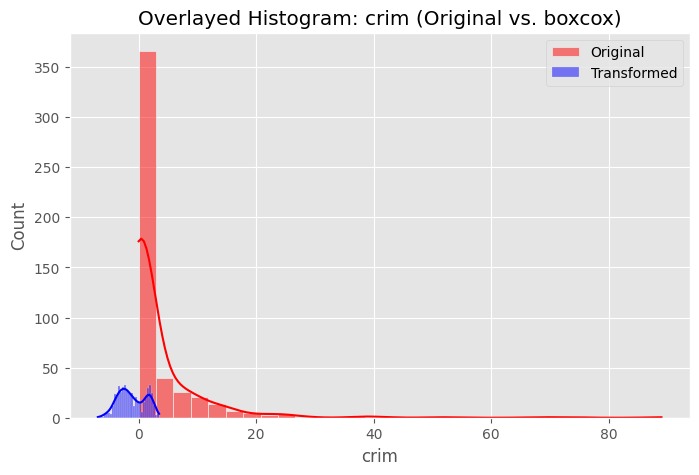

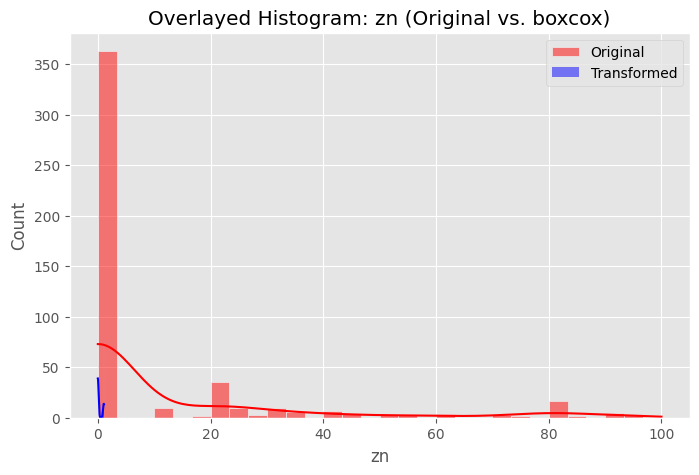

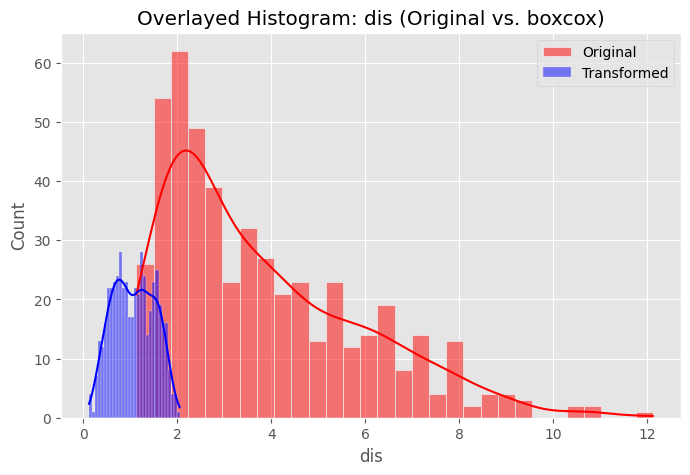

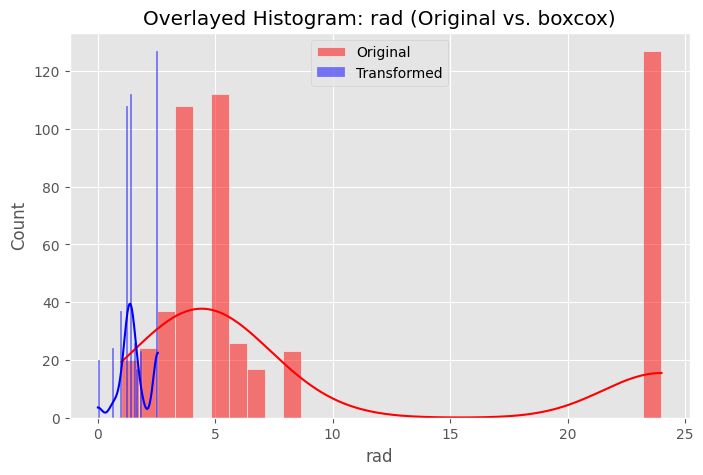

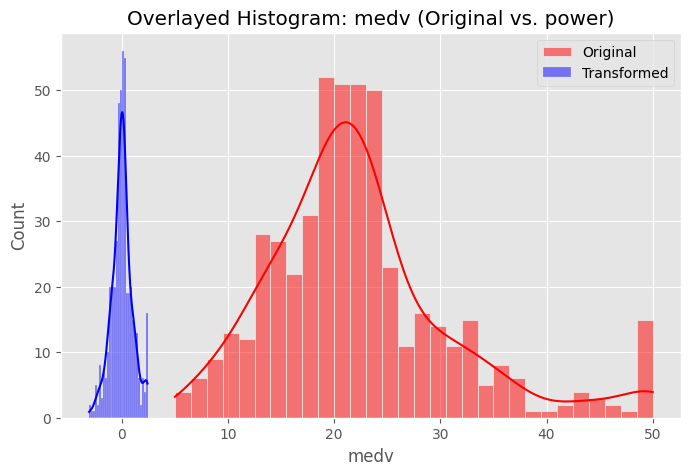


✅ Completed Transformations for Highly Skewed Features.

🔹 Applying Winsorization to Moderately Skewed Features...


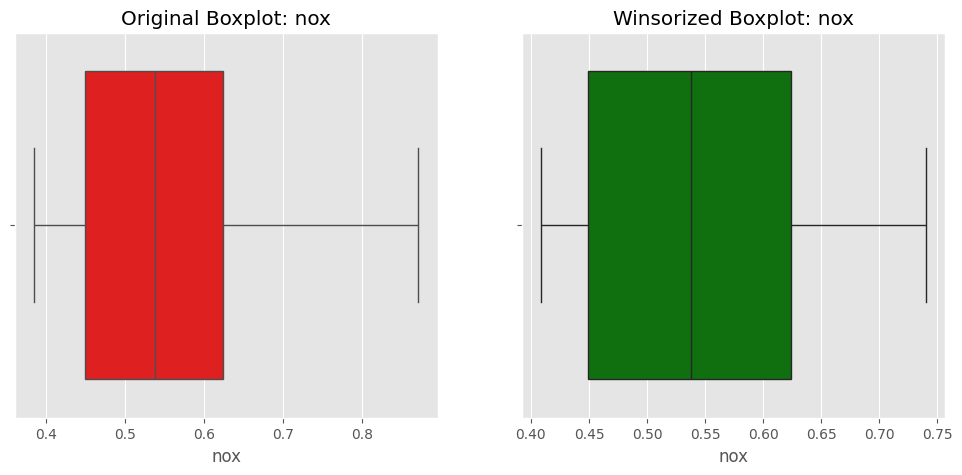

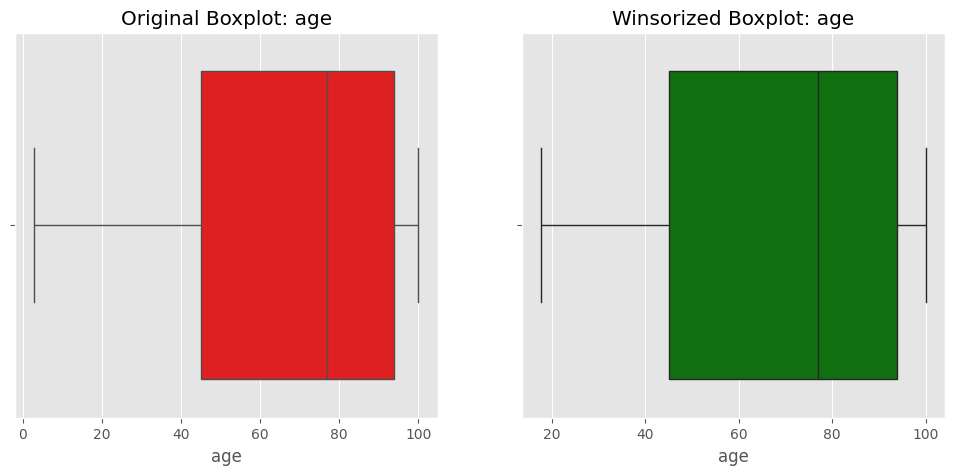

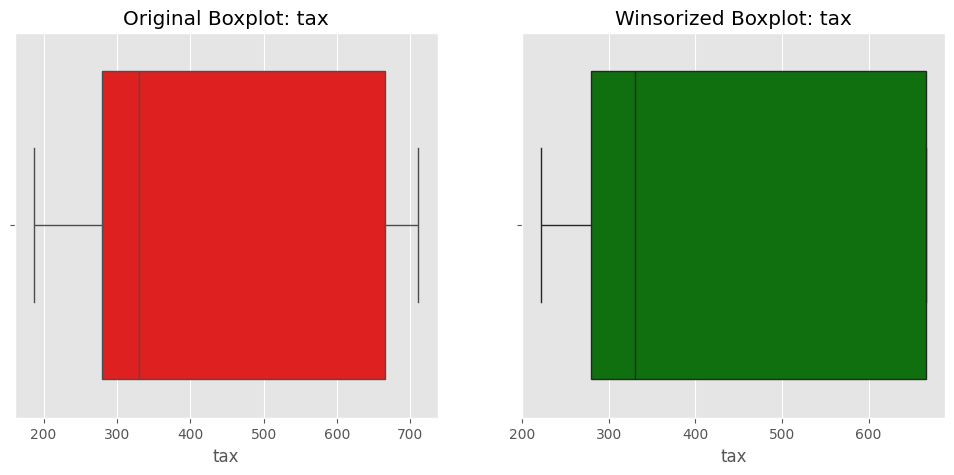

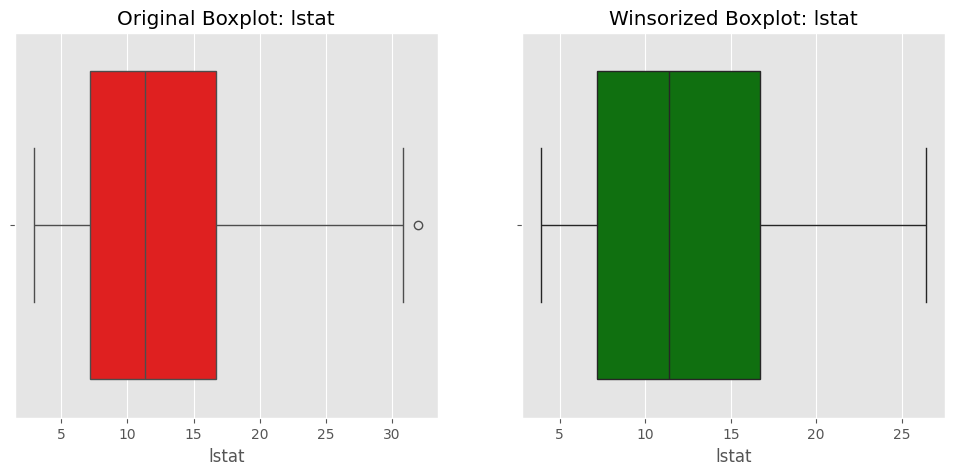


✅ Completed Winsorization for Moderately Skewed Features.

 Skew Handling Completed. Returning Transformed DataFrame.


In [17]:
# Main function to apply skew handling
def skew_handling(df, highly_skewed, moderately_skewed):
    df = ipp.handle_high_skew(df, highly_skewed)  # Handling high skew
    ipp.interModel(df, predictor_variable, "High_skew")
    df = ipp.handle_moderate_skew(df, moderately_skewed)  # Handling moderate skew
    ipp.interModel(df, predictor_variable, "Moderate_skew")
    
    print("\n Skew Handling Completed. Returning Transformed DataFrame.")
    return df

df_skew = skew_handling(df_04, highly_skewed, moderately_skewed)

In [18]:
try:
    with open(ipp.json_file_path, "r") as file:
        status_data = ipp.json.load(file)
except FileNotFoundError:
    # If the file doesn't exist, initialize an empty structure
    status_data = {}

# Now you can safely modify the status_data object
status_data["pre_processing"]["Skew"]["Low"]["handling"] = False
status_data["pre_processing"]["Skew"]["Low"]["features"] = low_skew

# Write the updated status back to the file
with open(ipp.json_file_path, "w") as file:
    ipp.json.dump(status_data, file, indent=4)

In [19]:
df_outlier_cleaned.skew()

crim       5.482570
zn         2.245989
indus      0.319651
chas       3.416749
nox        0.753395
rm         0.496920
age       -0.592338
dis        1.014604
rad        1.025585
tax        0.690025
ptratio   -0.815134
lstat      0.759202
medv       1.110816
dtype: float64

In [20]:
# print(df_skew.head(2))
df_skew.skew()

indus          0.319651
nox            0.401849
rm             0.496920
age           -0.522805
tax            0.710441
lstat          0.605283
crim_boxcox    0.095555
zn_boxcox      1.069651
dis_boxcox     0.029783
rad_boxcox     0.016575
medv_power     0.014445
dtype: float64

In [21]:
df_skew

,indus,nox,rm,age,tax,lstat,crim_boxcox,zn_boxcox,dis_boxcox,rad_boxcox,medv_power
1,2.31,0.538,6.575,65.2,296,4.98,-6.937919,1.026135,1.258363,0.000000,0.330263
2,7.07,0.469,6.421,78.9,242,9.14,-4.490041,0.000000,1.410328,0.659998,0.057067
3,7.07,0.469,7.185,61.1,242,4.03,-4.491163,0.000000,1.410328,0.659998,1.337625
4,2.18,0.458,6.998,45.8,222,3.92,-4.232270,0.000000,1.561236,1.016894,1.229535
5,2.18,0.458,7.147,54.2,222,5.33,-3.144443,0.000000,1.561236,1.016894,1.458451
...,...,...,...,...,...,...,...,...,...,...,...
502,11.93,0.573,6.593,69.1,273,9.67,-3.279151,0.000000,0.843658,0.000000,0.150638
503,11.93,0.573,6.120,76.7,273,9.08,-3.738595,0.000000,0.774017,0.000000,-0.063748
504,11.93,0.573,6.976,91.0,273,5.64,-3.321312,0.000000,0.726731,0.000000,0.319313
505,11.93,0.573,6.794,89.3,273,6.48,-2.527527,0.000000,0.811777,0.000000,0.104182


In [22]:
ipp.workflow(df_skew, predictor_variable)

In [23]:
## Indpendent and dependent features
from sklearn.model_selection import train_test_split
X = df_skew.drop([predictor_variable], axis=1)
y = df_skew[predictor_variable]

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# scaler_required_models = {
#     "LinearRegression": LinearRegression(),
#     "Ridge": Ridge(),
#     "Lasso": Lasso(),
#     "SVR": SVR(),
#     "KNeighbors": KNeighborsRegressor()
# }

# non_scaler_models = {
#     "DecisionTree": DecisionTreeRegressor(),
#     "RandomForest": RandomForestRegressor(),
#     "GradientBoosting": GradientBoostingRegressor()
# }

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# pipelines = {}

# # Scaler-sensitive models
# for name, model in scaler_required_models.items():
#     pipe = Pipeline([
#         ('scaler', StandardScaler()),
#         ('model', model)
#     ])
#     pipe.fit(X_train, y_train)
#     pipelines[name] = pipe

# # Scale-invariant models (no scaler)
# for name, model in non_scaler_models.items():
#     pipe = Pipeline([
#         ('model', model)
#     ])
#     pipe.fit(X_train, y_train)
#     pipelines[name] = pipe


In [25]:
# for name, pipe in pipelines.items():
#     y_pred = pipe.predict(X_test)
#     score = r2_score(y_test, y_pred)
#     print(f"{name}: R2 Score = {score:.4f}")


In [26]:
def log_model_result(result_entry: dict, json_file_path: str):
    import json, os

    if not os.path.exists(json_file_path):
        raise FileNotFoundError(f"{json_file_path} not found")

    with open(json_file_path, "r") as f:
        json_data = json.load(f)

    section = result_entry.get("section")
    model_results = result_entry.get("models", {})
    flags = result_entry.get("flags", {})

    # Exit if nothing to log
    if section not in ["modeling", "hyperparameter_tuning"] or not model_results:
        return  # No-op

    if section not in json_data:
        json_data[section] = {}

    for model_name, metrics in model_results.items():
        # If required keys are missing, skip
        if not {"train", "test", "r2_score"}.issubset(metrics.keys()):
            continue

        json_data[section][model_name] = metrics

    # Apply section-level flags if any
    for key, value in flags.items():
        json_data[section][key] = value

    with open(json_file_path, "w") as f:
        json.dump(json_data, f, indent=4)


In [27]:
# Function to pickle the model and return the file path
def save_model(model, name):
    timestamp = ipp.datetime.now().strftime("%Y%m%d_%H%M%S")
    file_name = f"{name}_{timestamp}.pkl"
    file_path = ipp.os.path.join(ipp.model_dir, file_name)
    
    with open(file_path, "wb") as f:
        ipp.pickle.dump(model, f)

    return file_name  # Returning only the file name to store in JSON

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import os
from sklearn.linear_model import LassoCV, Ridge, RidgeCV, ElasticNet, ElasticNetCV

# === Define models ===
scaler_required_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "SVR": SVR(),
    "KNeighbors": KNeighborsRegressor()
}

non_scaler_models = {
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor()
}

# === Split data ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipelines = {}
model_metrics = {}

# === Train scaler-required models ===
for name, model in scaler_required_models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    train_score = r2_score(y_train, y_train_pred)
    test_score = r2_score(y_test, y_test_pred)

    model_file = save_model(pipe, name)
    
    model_metrics[name] = {
        "train": train_score,
        "test": test_score,
        "r2_score": test_score,
        "model": model_file
    }

# === Train non-scaler models ===
for name, model in non_scaler_models.items():
    pipe = Pipeline([
        ('model', model)
    ])
    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    train_score = r2_score(y_train, y_train_pred)
    test_score = r2_score(y_test, y_test_pred)

    model_file = save_model(pipe, name)

    model_metrics[name] = {
        "train": train_score,
        "test": test_score,
        "r2_score": test_score,
        "model": model_file
    }

# === Prepare structured dict for status.json logging ===
result_entry = {
    "section": "modeling",
    "models": model_metrics,
    "flags": {
        "efficiency": False  # set True manually if needed
    }
}

# === Log to status.json ===
json_file_path = os.path.join("model_dump", "status.json")
log_model_result(result_entry, json_file_path)


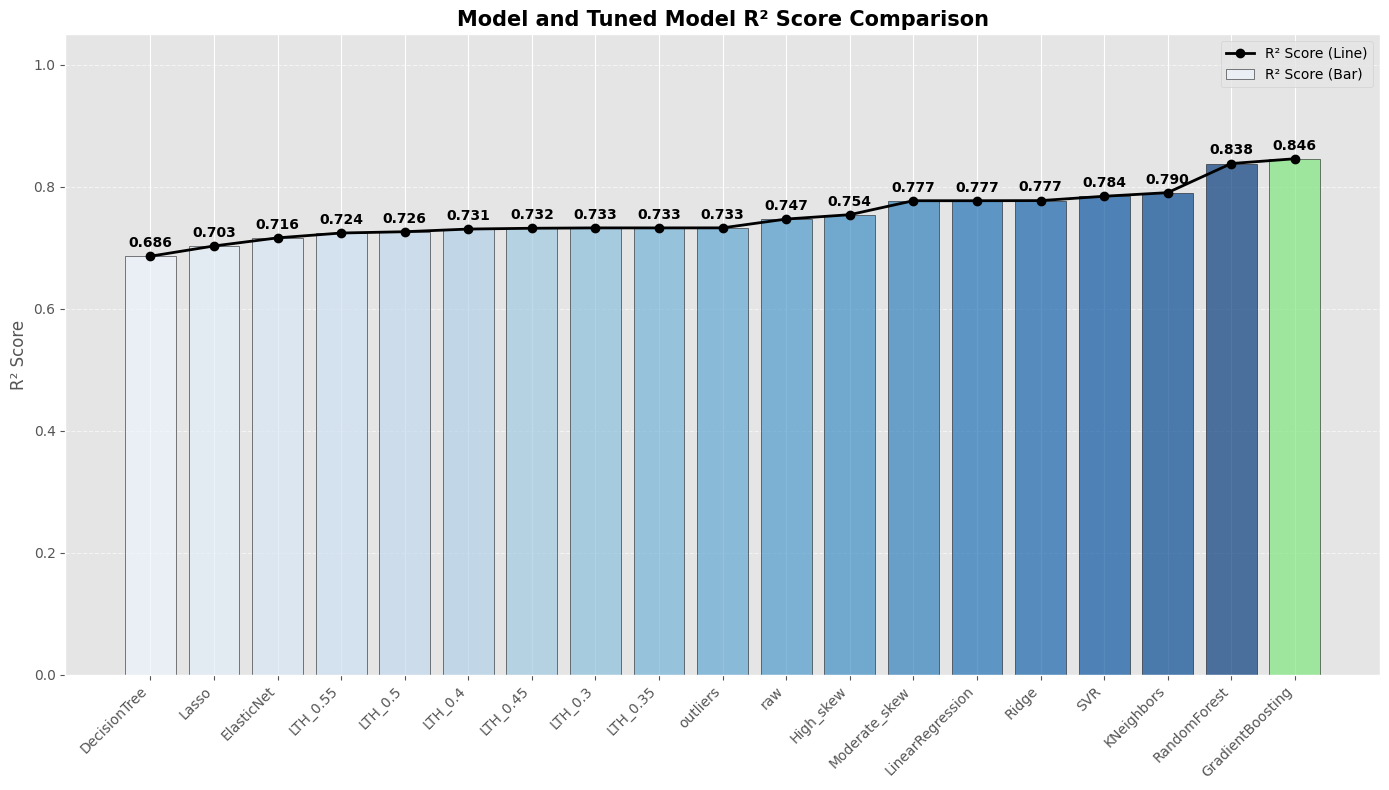

In [29]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
json_file_path = os.path.join(ipp.model_dir, "status.json")

with open(json_file_path, "r") as f:
    data = json.load(f)

# Extract models and r2_scores
models = []
r2_scores = []

# From modeling
for model_name, model_info in data.get("modeling", {}).items():
    if isinstance(model_info, dict) and "r2_score" in model_info:
        models.append(model_name)
        r2_scores.append(model_info["r2_score"])

# From hyperparameter_tuning
for model_name, model_info in data.get("hyperparameter_tuning", {}).items():
    if isinstance(model_info, dict) and "r2_score" in model_info:
        models.append(model_name)
        r2_scores.append(model_info["r2_score"])

# Sort models by R² score (ascending)
model_scores = sorted(zip(models, r2_scores), key=lambda x: x[1])
models_sorted, r2_scores_sorted = zip(*model_scores)

# Color palette: last model = light green
base_colors = sns.color_palette("Blues", len(models_sorted)-1)
colors = list(base_colors) + [(0.5, 0.9, 0.5)]  # RGB for light green

# Plot
plt.figure(figsize=(14, 8))
bars = plt.bar(models_sorted, r2_scores_sorted, color=colors, edgecolor="black", alpha=0.7, label="R² Score (Bar)")
plt.plot(models_sorted, r2_scores_sorted, marker="o", color="black", linewidth=2, label="R² Score (Line)")

# Value labels
for bar, score in zip(bars, r2_scores_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015, f"{score:.3f}",
             ha="center", fontsize=10, fontweight="bold")

# Labels and aesthetics
plt.ylabel("R² Score", fontsize=12)
plt.title("Model and Tuned Model R² Score Comparison", fontsize=15, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [30]:
# Load encrypted content and key from status.json
with open(ipp.json_file_path, "r") as f:
    data = json.load(f)
    encrypted_model_mind = data["Model_Mind"]
    encryption_key = data["key"]

# Decrypt
decrypted_model_mind = ipp.decrypt_model_mind_section(encrypted_model_mind, encryption_key)
print(decrypted_model_mind)

{'actual_model': [{'model': 'Gradient Boosting', 'r2_score': '0.814'}, {'model': 'Random Forest', 'r2_score': '0.803'}, {'model': 'Linear Regression', 'r2_score': '0.773'}], 'predicted_model': [{'model': 'Ridge Regression', 'confidence_score': '100'}, {'model': 'Lasso Regression', 'confidence_score': '100'}, {'model': 'ElasticNet Regression', 'confidence_score': '100'}]}
